V* converged after 67 iterations.
c = 0.03
tau_exec = 0.025
ideal lower boundary: b=0.166, log10-odds=-0.701
ideal upper boundary: b=0.834, log10-odds=0.701


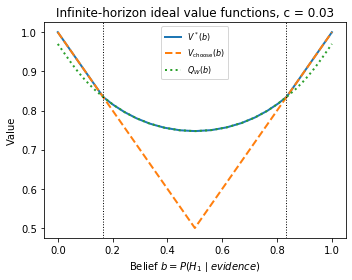

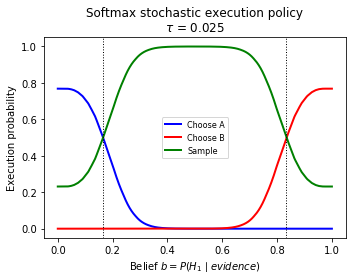

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# ============================================================
# 1. Define 16 stimulus types and their probabilities under H0/H1
# ============================================================

mu = 2.2
sigma = 5.0
x = np.linspace(-15, 15, 500)

pdf_left = norm.pdf(x, -mu, sigma)    # H0 / Target A
pdf_right = norm.pdf(x, mu, sigma)    # H1 / Target B

# log10 likelihood ratio: log10 P(x|H1) / P(x|H0)
log_ratio = np.log10(pdf_right / pdf_left)

target_log_ratios = np.array([
    -0.8, -0.7, -0.6, -0.5,
    -0.4, -0.3, -0.2, -0.1,
     0.1,  0.2,  0.3,  0.4,
     0.5,  0.6,  0.7,  0.8
])

x_targets = np.interp(target_log_ratios, log_ratio, x)

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

pB = pB_raw / pB_raw.sum()
pA = pA_raw / pA_raw.sum()

# ============================================================
# 2. Infinite-horizon value iteration (ideal representation/integration)
# ============================================================

c = 0.03
tau_exec = 0.025   # execution temperature; adjust if you want softer/harder boundaries

R_correct = 1.0
R_wrong = 0.0

N_b = 1001
b_grid = np.linspace(0, 1, N_b)

eps = 1e-12

# Immediate stop values
Q0 = (1 - b_grid) * R_correct + b_grid * R_wrong   # choose H0
Q1 = b_grid * R_correct + (1 - b_grid) * R_wrong   # choose H1
V_choose = np.maximum(Q0, Q1)

def compute_V_star(pA, pB, c, b_grid, V_choose, tol=1e-10, max_iter=100000):
    """
    Ideal infinite-horizon value iteration.
    """
    V = V_choose.copy()

    for iteration in range(max_iter):
        V_old = V.copy()
        Q_wait = np.zeros_like(b_grid)

        for j, b in enumerate(b_grid):
            expected_future_value = 0.0

            for i in range(len(pA)):
                q_i = b * pB[i] + (1 - b) * pA[i]
                if q_i > 0:
                    b_next = (b * pB[i]) / q_i
                    expected_future_value += q_i * np.interp(
                        b_next, b_grid, V_old
                    )

            Q_wait[j] = -c + expected_future_value

        V = np.maximum(V_choose, Q_wait)

        diff = np.max(np.abs(V - V_old))
        if diff < tol:
            print(f"V* converged after {iteration + 1} iterations.")
            break
    else:
        print("Warning: value iteration did not converge.")

    return V, Q_wait

V_star, Q_wait = compute_V_star(pA, pB, c, b_grid, V_choose)

# derive the ideal hard boundary
stop_region = V_choose >= Q_wait
continue_region = ~stop_region

if np.any(continue_region):
    lower_b = b_grid[continue_region][0]
    upper_b = b_grid[continue_region][-1]
else:
    lower_b = 0.5
    upper_b = 0.5

lower_log_boundary = np.log10(
    np.clip(lower_b, eps, 1 - eps) / np.clip(1 - lower_b, eps, 1 - eps)
)
upper_log_boundary = np.log10(
    np.clip(upper_b, eps, 1 - eps) / np.clip(1 - upper_b, eps, 1 - eps)
)

print(f"c = {c:.2f}")
print(f"tau_exec = {tau_exec:.3f}")
print(f"ideal lower boundary: b={lower_b:.3f}, log10-odds={lower_log_boundary:.3f}")
print(f"ideal upper boundary: b={upper_b:.3f}, log10-odds={upper_log_boundary:.3f}")

# ============================================================
# 3. Plot V_choose, Q_wait, and V_star
# ============================================================

plt.figure(figsize=(5, 4))
plt.plot(b_grid, V_star, label=r"$V^*(b)$", linewidth=2)
plt.plot(b_grid, V_choose, "--", label=r"$V_{\mathrm{choose}}(b)$", linewidth=2)
plt.plot(b_grid, Q_wait, ":", label=r"$Q_W(b)$", linewidth=2)

plt.axvline(lower_b, color="black", linestyle=":", linewidth=1)
plt.axvline(upper_b, color="black", linestyle=":", linewidth=1)

plt.xlabel(r"Belief $b=P(H_1 \mid evidence)$")
plt.ylabel("Value")
plt.title(f"Infinite-horizon ideal value functions, c = {c}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ============================================================
# 4. Stochastic execution policy (softmax over Q0, Q1, QW)
# ============================================================

def softmax_3actions(Q0, Q1, QW, tau):
    """
    Return probabilities for actions 0, 1, and W.
    """
    Q_stack = np.vstack([Q0, Q1, QW]) / tau
    Q_stack = Q_stack - np.max(Q_stack, axis=0, keepdims=True)
    exp_Q = np.exp(Q_stack)
    probs = exp_Q / np.sum(exp_Q, axis=0, keepdims=True)
    return probs

policy_probs = softmax_3actions(Q0, Q1, Q_wait, tau_exec)
p_choose0 = policy_probs[0]
p_choose1 = policy_probs[1]
p_sample = policy_probs[2]

log_odds_grid = np.log10(
    np.clip(b_grid, eps, 1 - eps) / np.clip(1 - b_grid, eps, 1 - eps)
)
"""
# ============================================================
# 4.1 Softmax stochastic execution policy
# ============================================================

def stable_softmax(Q, tau):
    Q_scaled = Q / tau
    Q_scaled = Q_scaled - np.max(Q_scaled, axis=0, keepdims=True)
    exp_Q = np.exp(Q_scaled)
    return exp_Q / np.sum(exp_Q, axis=0, keepdims=True)

Q_all = np.vstack([
    Q0,
    Q1,
    Q_wait
])

policy_soft = stable_softmax(Q_all, tau_exec)

p_choose_A = policy_soft[0, :]
p_choose_B = policy_soft[1, :]
p_sample = policy_soft[2, :]
"""
# ============================================================
# 4.2 Plot soft execution probabilities as function of belief
# ============================================================

plt.figure(figsize=(5, 4))

plt.plot(b_grid, p_choose0, color="blue", linewidth=2, label="Choose A")
plt.plot(b_grid, p_choose1, color="red", linewidth=2, label="Choose B")
plt.plot(b_grid, p_sample, color="green", linewidth=2, label="Sample")

plt.axvline(lower_b, color="black", linestyle=":", linewidth=1)
plt.axvline(upper_b, color="black", linestyle=":", linewidth=1)

plt.xlabel(r"Belief $b=P(H_1 \mid evidence)$")
plt.ylabel("Execution probability")
plt.title(f"Softmax stochastic execution policy\n" + r"$\tau$" + f" = {tau_exec}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 5. Simulate 5*10^4 trials
# ============================================================

n_trials = 5 * 10**4
max_timestep = 10

rng = np.random.default_rng(1)

sim_rows = []

for trial in range(n_trials):

    true_H = rng.integers(0, 2)   # 0 = H0 / A, 1 = H1 / B
    evidence_sum = 0.0

    for t in range(1, max_timestep + 1):

        if true_H == 0:
            stim_idx = rng.choice(len(pA), p=pA)
        else:
            stim_idx = rng.choice(len(pB), p=pB)

        evidence_sum += target_log_ratios[stim_idx]

        b = 1.0 / (1.0 + 10.0 ** (-evidence_sum))

        q0_t = np.interp(b, b_grid, Q0)
        q1_t = np.interp(b, b_grid, Q1)
        qw_t = np.interp(b, b_grid, Q_wait)

        probs_t = softmax_3actions(
            np.array([q0_t]),
            np.array([q1_t]),
            np.array([qw_t]),
            tau_exec
        ).flatten()

        action = rng.choice([0, 1, 2], p=probs_t)

        sim_rows.append({
            "trial": trial,
            "true_H": true_H,
            "time_step": t,
            "stim_idx": stim_idx,
            "evidence_sum": evidence_sum,
            "belief": b,
            "action": action
        })

        if action in [0, 1]:
            break

df_sim = pd.DataFrame(sim_rows)

print(df_sim.head())
print(df_sim["action"].value_counts())

   trial  true_H  time_step  stim_idx  evidence_sum    belief  action
0      0       0          1        12           0.5  0.759747       1
1      1       1          1        14           0.7  0.833662       1
2      2       1          1        12           0.5  0.759747       2
3      2       1          2         9           0.7  0.833662       1
4      3       0          1         8           0.1  0.557312       2
2    159652
1     23862
0     23854
Name: action, dtype: int64


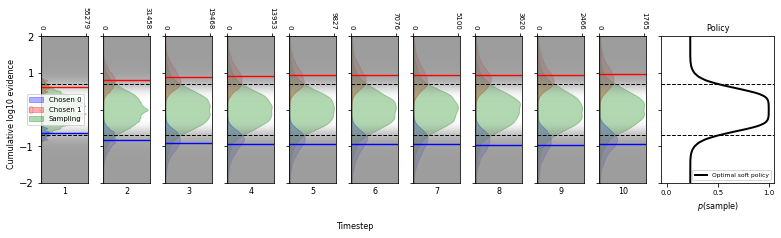

In [13]:
# ============================================================
# 6. Plot distributions + soft boundary shadow + policy curves
# ============================================================

colors = {
    0: "blue",
    1: "red",
    2: "green"
}

labels = {
    0: 'Chosen 0', 
    1: 'Chosen 1', 
    2: 'Sampling'
}

# discrete colors for time steps
time_colors = plt.cm.tab10(np.arange(max_timestep))
"""
fig, axes = plt.subplots(
    1,
    max_timestep + 1,
    figsize=(10.8, 3.2),
    sharey=True,
    gridspec_kw={"width_ratios": [1] * max_timestep + [2.2]}
)
"""
fig, axes = plt.subplots(
    1,
    max_timestep + 1,
    figsize=(11.5, 3.4),
    sharey=True,
    gridspec_kw={"width_ratios": [1] * max_timestep + [2.4]}
)
    
dist_axes = axes[:-1]
policy_ax = axes[-1]

y_min = -2.0
y_max = 2.0
y_grid = np.linspace(y_min, y_max, 500)

# p(sample) evaluated on y_grid
p_sample_y = np.interp(y_grid, log_odds_grid, p_sample)

# ------------------------------------------------------------
# Left side: time-step panels with empirical distributions
# ------------------------------------------------------------

for t in range(1, max_timestep + 1):

    ax = dist_axes[t - 1]
    timestep_data = df_sim[df_sim["time_step"] == t]

    max_density = 0.0

    # gray soft-boundary shadow from p(sample)
    for k in range(len(y_grid) - 1):
        alpha_k = 1 - p_sample_y[k]
        if alpha_k > 0.003:
            ax.axhspan(
                y_grid[k],
                y_grid[k + 1],
                color="gray",
                alpha=alpha_k,
                linewidth=0
            )

    for action in [0, 1, 2]:
        action_data = timestep_data[timestep_data["action"] == action]
        if action_data.empty:
            continue

        ev = action_data["evidence_sum"].to_numpy()

        if len(ev) < 3 or np.std(ev) == 0:
            continue

        kde = gaussian_kde(ev)
        density = kde(y_grid)

        density_scaled = density * len(ev)
        max_density = max(max_density, density_scaled.max())

        ax.fill_betweenx(
            y_grid,
            0,
            density_scaled,
            color=colors[action],
            alpha=0.3,
            label=labels[action] if t == 1 else None
        )

        if action in [0, 1]:
            mean_ev = np.mean(ev)
            ax.axhline(mean_ev, color=colors[action], linewidth=1.4)

    # Put legend here, after all fill_betweenx calls
    if t == 1:
        ax.legend(loc="upper left", fontsize=7, frameon=True)
    # dashed ideal boundaries
    ax.axhline(lower_log_boundary, color="black", linestyle="--", linewidth=1)
    ax.axhline(upper_log_boundary, color="black", linestyle="--", linewidth=1)

    ax.set_ylim(y_min, y_max)

    if max_density > 0:
        ax.set_xlim(0, max_density * 1.05)
        ax.set_xticks([0, int(max_density)])
    else:
        ax.set_xlim(0, 1)
        ax.set_xticks([0, 1])

    ax.xaxis.set_ticks_position("top")
    ax.tick_params(axis="x", top=True, labeltop=True, labelbottom=False)

    ax.set_xticklabels(
        [str(int(x)) for x in ax.get_xticks()],
        rotation=270,
        fontsize=7
    )

    ax.set_xlabel(str(t), fontsize=8)

# ------------------------------------------------------------
# Right side: policy curves p(sample | evidence)
# black solid = optimal soft policy
# colored dashed = empirical policy by time step
# ------------------------------------------------------------

# optimal soft policy (same for every t, infinite horizon)
policy_ax.plot(
    p_sample_y,
    y_grid,
    color="black",
    linewidth=2,
    label="Optimal soft policy"
)

# empirical p(sample | evidence) by timestep
"""
n_bins = 60
ev_bins = np.linspace(y_min, y_max, n_bins + 1)
ev_centers = 0.5 * (ev_bins[:-1] + ev_bins[1:])

for t in range(1, max_timestep + 1):
    timestep_data = df_sim[df_sim["time_step"] == t]
    ev = timestep_data["evidence_sum"].to_numpy()
    is_sampling = (timestep_data["action"] == 2).astype(float).to_numpy()

    p_emp = np.full_like(ev_centers, np.nan, dtype=float)

    for i in range(n_bins):
        mask = (ev >= ev_bins[i]) & (ev < ev_bins[i + 1])
        if mask.sum() >= 10:
            p_emp[i] = is_sampling[mask].mean()

    policy_ax.plot(
        p_emp,
        ev_centers,
        color=time_colors[t - 1],
        linestyle="--",
        linewidth=1.2,
        label=f"t={t}"
    )
"""
policy_ax.axhline(lower_log_boundary, color="black", linestyle="--", linewidth=1)
policy_ax.axhline(upper_log_boundary, color="black", linestyle="--", linewidth=1)

policy_ax.set_xlim(-0.05, 1.05)
policy_ax.set_xticks([0, 0.5, 1.0])
policy_ax.set_xlabel(r"$p(\mathrm{sample})$", fontsize=8)
policy_ax.set_title("Policy", fontsize=8)
policy_ax.tick_params(axis="x", labelsize=7)

policy_ax.legend(
    loc="lower right",
    fontsize=6,
    ncol=2,
    frameon=True
)

# shared labels
fig.text(0.48, 0.03, "Timestep", ha="center", fontsize=8)
fig.text(
    0.06,
    0.5,
    "Cumulative log10 evidence",
    va="center",
    rotation="vertical",
    fontsize=8
)

for ax in dist_axes:
    ax.label_outer()

dist_axes[0].legend(loc="best", fontsize=7)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.98])
plt.show()